In [39]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

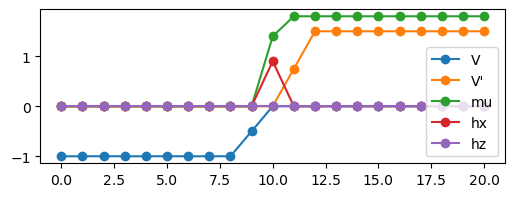

In [40]:
widthD = 10
widthF = 1
widthP = 10

X, Y = widthD+widthF+widthP, 100
lattice = Lattice(X, Y)

t = 1
T = 0.01

muD = 0.0 * t
muP = 1.8 * t
muF = 1.4 * t
mu = np.zeros(lattice.X)
mu[:widthD] = muD
mu[widthD:widthD + widthF] = muF
mu[widthD + widthF:] = muP

hx0 = 0.9 * t
hx = np.zeros_like(mu)
hx[widthD:widthD + widthF] = hx0

hz0 = 0 * t
hz = np.zeros_like(mu)
hz[:widthD] = hz0

U0 = -1.0 * t
U = U0 * np.ones(lattice.X)
U[widthD:] = 0
U[widthD-1] = U0/2

V0 = 4.0 * t
V = V0 * np.ones(lattice.X)
V[widthD:] = 0
V[widthD-1] = V0/2

V_prime0 = 1.5 * t
V_prime = V_prime0 * np.ones(lattice.X)
V_prime[:widthF+widthD] = 0
V_prime[widthF+widthD] = V_prime0/2

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(hx, '-o', label='hx')
plt.plot(hz, '-o', label='hz')

plt.legend()

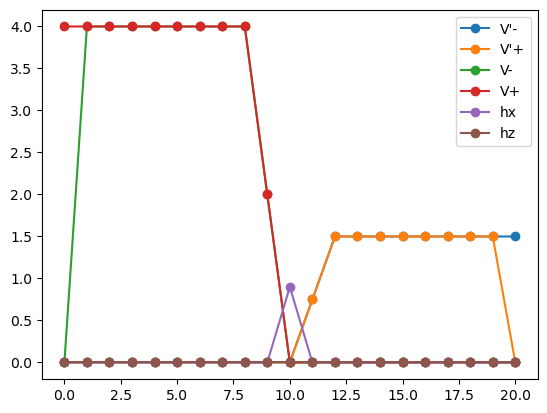

In [41]:
V_plus = np.r_[V[:-1], [0]]
V_minus = np.r_[[0], V[1:]]
Vprime_plus = np.r_[V_prime[:-1], [0]]
Vprime_minus = np.r_[[0], V_prime[1:]]

plt.plot(Vprime_minus, "-o", label="V'-")
plt.plot(Vprime_plus, "-o", label="V'+")
plt.plot(V_minus, "-o", label="V-")
plt.plot(V_plus, "-o", label="V+")
plt.plot(hx, '-o', label='hx')
plt.plot(hz, '-o', label='hz')
plt.legend()

In [42]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, g_s=V,
                F_init=[0.3, 0.3, -0.3, -0.3],
                Fuu_init=[0.1, -0.1, 0.1j, -0.1j],
                Fdd_init=[0.1, -0.1, 0.1j, -0.1j],
                hx=hx, hz=hz)

In [ ]:
bdg_sc(H, atol=1e-3, rtol=0.1, maxiter=1000, temperature=T,verbose=True)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 0.033179408929658004
Relative error: 33179408929.658005
Average old: 0j
Average: (0.001281821661049444+0j)
F_xplus:
Absolute error: 0.20233584562755025
Relative error: 29197662545.85092
Average old: (0.135+0j)
Average: (0.16309927716144174+0j)
F_xmin:
Absolute error: 0.20019571237215592
Relative error: 23766177442.622665
Average old: (0.135+0j)
Average: (0.16311200173830123+0j)
F_yplus:
Absolute error: 0.20016233611719655
Relative error: 89140862001.56819
Average old: (-0.1285714285714286+0j)
Average: (-0.15775323273985667+0.0005708683222433428j)
F_ymin:
Absolute error: 0.20016233611719655
Relative error: 89140862001.56819
Average old: (-0.1285714285714286+0j)
Average: (-0.15775323273985667-0.0005708683222433428j)
Fuu_xplus:
Absolute error: 0.06389867352519805
Relative error: 49438031251.62762
Average old: (0.045000000000000005+0j)
Average: (0.04952266167354084+0j)
Fuu_xmin:
Absolute error: 0.07254724306158325
Relative error: 22545669734.80229
Average old: (-0.05+0j

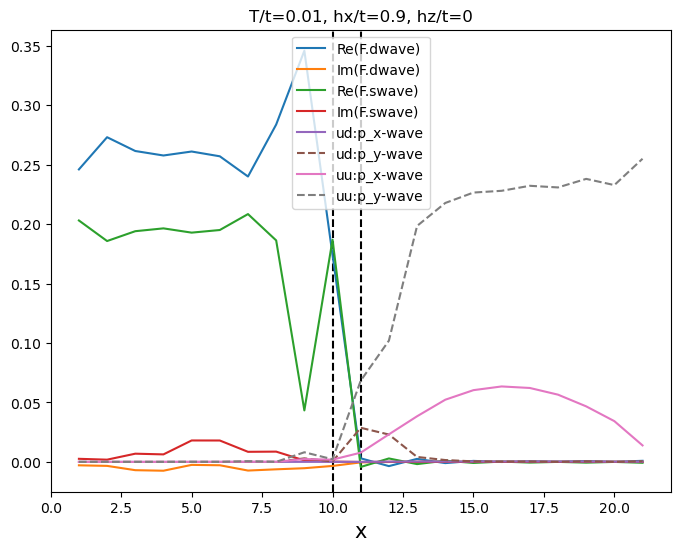

In [ ]:
x = np.arange(1, widthD + widthF + widthP + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}, hx/t={hx0}, hz/t={hz0}")
axs.axvline(widthD, color='black', linestyle='--')
axs.axvline(widthD+widthF, color='black', linestyle='--')
axs.plot(x, np.real(F.dwave), label="Re(F.dwave)")
axs.plot(x, np.imag(F.dwave), label="Im(F.dwave)")
axs.plot(x, np.real(F.swave), label="Re(F.swave)")
axs.plot(x, np.imag(F.swave), label="Im(F.swave)")
axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.plot(x, np.abs(Fuu.px), label="uu:p_x-wave")
axs.plot(x, np.abs(Fuu.py), "--", label="uu:p_y-wave")
axs.set_xlabel("x", fontsize=15)
axs.legend()
plt.show()

In [ ]:
temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.25 + 1e-12, 0.01),
    np.arange(0.26, 0.6 + 1e-12, 0.002 )
])  # 164 temps total
print(len(temps))

205
